In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("50_Startups.csv")

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156994.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.85,311613.28,New York,152211.77
9,94657.16,145077.58,282574.31,New York,125370.37


In [4]:
dataset=pd.get_dummies(dataset,dtype=int ,drop_first=True)
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156994.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.85,311613.28,152211.77,0,1
9,94657.16,145077.58,282574.31,125370.37,0,1


In [5]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [6]:
Independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend',
       'State_Florida', 'State_New York']]

In [7]:
Independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.85,311613.28,0,1
9,94657.16,145077.58,282574.31,0,1


In [8]:
dependent=dataset[["Profit"]]

In [9]:
dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156994.12
6,156122.51
7,155752.60
8,152211.77
9,125370.37


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(Independent,dependent,test_size=0.3,random_state=0)

In [11]:
x_train

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
18,86419.70,153514.11,0.00,0,1
19,76253.86,113867.30,298664.47,0,0
16,94657.16,145077.58,282574.31,0,1
1,162597.70,151377.59,443898.53,0,0
10,91749.16,114175.79,294919.57,1,0
25,75328.87,144135.98,134050.07,1,0
24,64664.71,139553.16,137962.62,0,0
8,120542.52,148718.85,311613.28,0,1
6,134615.46,147198.87,127716.82,0,0
4,142107.34,91391.77,366168.42,1,0


In [12]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='poisson', splitter='best')
regressor=regressor.fit(x_train,y_train)


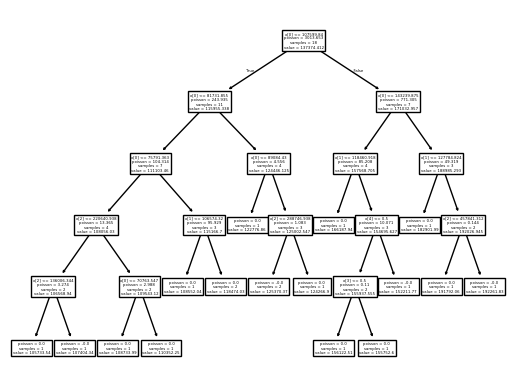

In [13]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [14]:
y_pred=regressor.predict(x_test)

In [15]:
from sklearn.metrics import r2_score


In [16]:
r_score=r2_score(y_test,y_pred)
r_score

0.9582832061126376